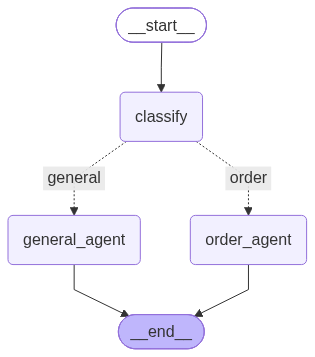

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    question: str
    answer: str
    category: str


def classify(state: State):
    if "order" in state["question"].lower():
        return {"category": "order"}

    return {"category": "general"}

def route_question(state: State):
    return state['category']

def order_agent(state: State):
    return {
        "answer": f"Handling your order question: {state['question']}"
    }


def general_agent(state: State):
    return {
        "answer": f"Handling your general question: {state['question']}"
    }


builder = StateGraph(State)

# Add nodes
builder.add_node("classify", classify)
builder.add_node("order_agent", order_agent)
builder.add_node("general_agent", general_agent)

# START → classify
builder.add_edge(START, "classify")

# classify → order_agent OR general_agent
builder.add_conditional_edges(
    "classify",
    route_question,
    {
        "order": "order_agent",
        "general": "general_agent",
    }
)

# Agents → END
builder.add_edge("order_agent", END)
builder.add_edge("general_agent", END)

graph = builder.compile()


graph


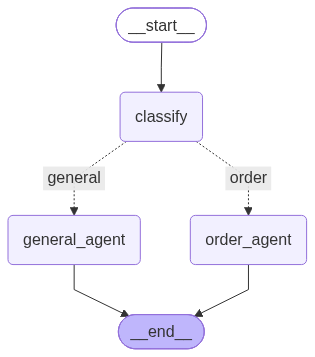

In [7]:
result = graph.invoke({
    "question": "Where is my pen?",
    "answer": ""
})

print(result)

{'question': 'Where is my pen?', 'answer': 'Handling your general question: Where is my pen?', 'category': 'general'}
